## Visualizing Filters of a Convolutional Neural Network

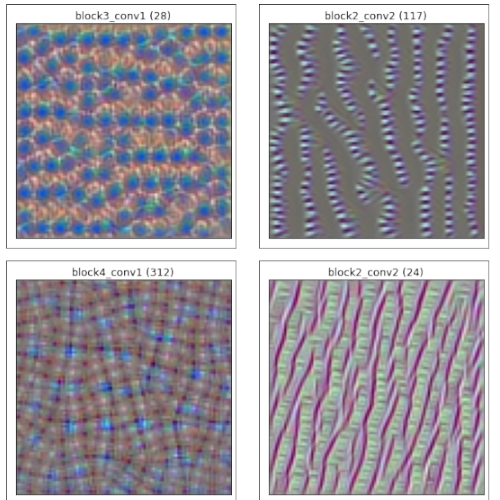

## Downloading the Model

In [ ]:
import tensorflow as tf
import random
import matplotlib.pyplot as plt

print('TensorFlow version', tf.__version__)

TensorFlow version 2.20.0


By setting this to False, we are cutting off the final decision-making head and keeping only the feature extraction factory (all the Conv and Pooling layers).

This downloads weights that have been pre-trained on over 14 million images (the ImageNet dataset). This network already perfectly knows how to detect edges, shapes, eyes, fur, wheels, and textures.

And we are selecting full colour images that are 96x96 pixels.

In [ ]:
model=tf.keras.applications.vgg16.VGG16(
    include_top=False, weights='imagenet',
    input_shape=(96, 96, 3)
)

model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 96, 96, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 48, 48, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

The resolution shrinks: It goes from 96x96 $\rightarrow$ 48x48 $\rightarrow$ 24x24 $\rightarrow$ 124x24 $\rightarrow$ 12x12. This happens exclusively at the _pool layers, which downsample the spatial area like max pooling step did.

The channel depth explodes: It goes from 3 (RGB) $\rightarrow$ 64 $\rightarrow$ 128 $\rightarrow$ 256 $\rightarrow$ 512.

"Params" are the individual weights (the numbers in the filters) that the network uses to detect features.

## Get Layer Output

This is feature extraction.

In [ ]:
def get_submodel(layer_name):
  return tf.keras.models.Model(
      model.input,
      model.get_layer(layer_name).output
  )

get_submodel('block1_conv2').summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 96, 96, 64)     │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,720 (151.25 KB)

 Trainable params: 38,720 (151.25 KB)

 Non-trainable params: 0 (0.00 B)

## Image Visualization

In [ ]:

def create_image():
    # Generates a truly random color noise image between 0.0 and 1.0
    return tf.random.uniform((96, 96, 3), minval=0.0, maxval=1.0)

def plot_image(image, title='random'):
    # Normalizes the image values to be safely between 0.0 and 1.0
    image = image - tf.math.reduce_min(image)
    image = image / tf.math.reduce_max(image)

    plt.imshow(image)
    plt.xticks([]) # Removes the X-axis pixel numbers
    plt.yticks([]) # Removes the Y-axis pixel numbers
    plt.title(title)
    plt.show()

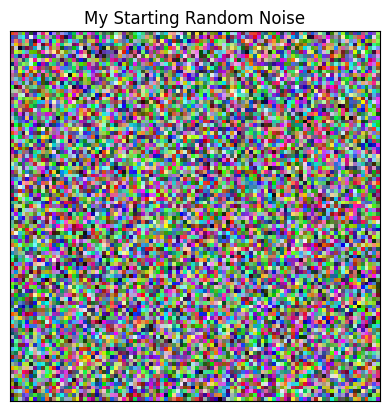

In [ ]:
# 1. Create the random noise image and save it to a variable
img = create_image()

# 2. Pass that image into your plotting function to see it on screen
plot_image(img, title="My Starting Random Noise")

## Training Loop

In [ ]:
import random
import tensorflow as tf

def visualize_filter(layer_name, f_index=None, iters=50):
    submodel = get_submodel(layer_name)
    num_filters = submodel.output.shape[-1]

    if f_index is None:
        f_index = random.randint(0, num_filters - 1)

    assert num_filters > f_index, 'f_index is out of bounds'

    image = create_image()
    verbose_step = int(iters / 10)

    for i in range(0, iters):
        with tf.GradientTape() as tape:
            # Tell TensorFlow to watch our image pixels because we want to change them
            tape.watch(image)

            # Pass image through submodel and target the specific filter index
            out = submodel(tf.expand_dims(image, axis=0))[:, :, :, f_index]
            loss = tf.math.reduce_mean(out)

        # Calculate gradients (how changing pixels changes the filter activation)
        grads = tape.gradient(loss, image)
        grads = tf.math.l2_normalize(grads)

        # GRADIENT ASCENT: Add gradients to the image to maximize the activation
        image += grads * 10

        # Print progress update
        if (i + 1) % verbose_step == 0:
            print(f'Iteration: {i + 1}, Loss: {loss.numpy():.4f}')

    # Plot the final engineered image!
    plot_image(image, f'{layer_name}, {f_index}')

## Final Results

['block1_conv1', 'block1_conv2', 'block2_conv1', 'block2_conv2', 'block3_conv1', 'block3_conv2', 'block3_conv3', 'block4_conv1', 'block4_conv2', 'block4_conv3', 'block5_conv1', 'block5_conv2', 'block5_conv3']
Iteration: 5, Loss: 7.5281
Iteration: 10, Loss: 22.5723
Iteration: 15, Loss: 36.6042
Iteration: 20, Loss: 50.7045
Iteration: 25, Loss: 64.3974
Iteration: 30, Loss: 79.1199
Iteration: 35, Loss: 94.4654
Iteration: 40, Loss: 110.3781
Iteration: 45, Loss: 127.8500
Iteration: 50, Loss: 146.1396


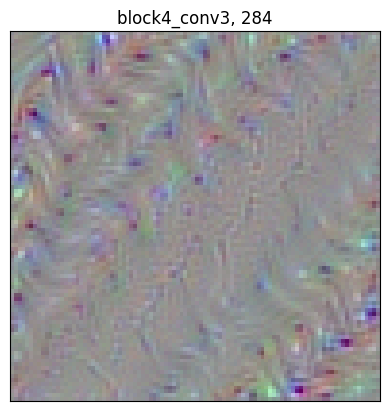

In [ ]:
# Print out all the available convolutional layers to choose from
print([layer.name for layer in model.layers if 'conv' in layer.name])

# The dropdown menu on the right lets you pick a layer dynamically!
layer_name = 'block4_conv3' #@param ['block1_conv1', 'block1_conv2', 'block2_conv1', 'block2_conv2', 'block3_conv1', 'block3_conv2', 'block3_conv3', 'block4_conv1', 'block4_conv2', 'block4_conv3', 'block5_conv1', 'block5_conv2', 'block5_conv3']

# Run the gradient ascent visualization loop on the selected layer
visualize_filter(layer_name)

Iteration: 10, Loss: 46.1721
Iteration: 20, Loss: 71.5813
Iteration: 30, Loss: 100.9810
Iteration: 40, Loss: 133.4119
Iteration: 50, Loss: 167.9374
Iteration: 60, Loss: 203.6684
Iteration: 70, Loss: 239.9338
Iteration: 80, Loss: 276.6964
Iteration: 90, Loss: 313.8114
Iteration: 100, Loss: 351.2296


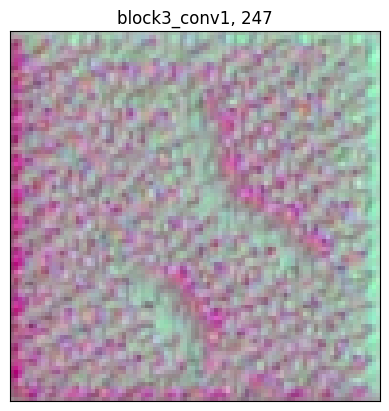

In [ ]:
# Select a deep layer that actually understands complex patterns
layer_name = 'block3_conv1'

# Give it 100 iterations to sharpen the details
visualize_filter(layer_name, iters=100)